# Borzoi perfomance

## 1. Setup and Libraries

In [1]:
# Setup and load required libraries
library(here)
devtools::load_all("/home/aviezerl/src/misha")
library(misha.ext)
library(tidyverse)
library(ggrepel)
library(tgutil)

options(gmax.data.size = 1e10)
options(gmultitasking = FALSE)
doMC::registerDoMC(cores = 72)

# Source utility functions
source(here("analysis/borzoi_utils.R"))
source(here("analysis/borzoi-plot.R"))

vertical_labs <- function() {
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))
}

# Setup misha
setwd(here())
gsetroot("/home/aviezerl/mm10")
gdb.reload()

here() starts at /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm

ℹ Loading misha

Attaching package: ‘misha.ext’


The following objects are masked from ‘package:misha’:

    gintervals.mark_overlaps, gintervals.normalize


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::edition_get()   masks testthat::edition_get()
✖ dplyr::filter()        masks stats::filter()
✖ dplyr::lag()           masks stats::lag()
✖ readr::local_edition() masks testthat::local_edition()
✖ tibble::repair_names() masks misha::repair_names()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## 2. Configuration

In [ ]:
# ============================================================
# Configuration
# ============================================================
# Centralized configuration for all analysis parameters

CONFIG <- list(
    # Chromosome splits
    test_chroms = c("chr4", "chr10", "chr14", "chr15"),
    val_chroms = c("chr8", "chr9"),

    # Thresholds
    T_q = 0.98,
    context_size = 200,
    iterator_size = 100,

    # Parallel processing
    n_cores = 72,

    # Reference tracks
    obs_k27_track = "jk.epipcg.pcg.CRJK_0364_k27me3_eb_j1_d4_a_norm",
    obs_k4_track = "jk.epipcg.pcg.CRJK_0411_k4me3_wt_to_wt_eb_d3",

    # SNS tracks
    sns_lm_track = "jk.epipcg.pred.eb4_xgb_lm_10test_seeds_gc_cg_noX",
    sns_brz2k_track = "jk.epipcg.pred.eb4_xgb_brz2k_seeds",

    # Output paths
    output_dir = here("output/borzoi-stats"),

    # Plot styling
    colors = list(
        train = "#2166AC",
        test = "#D6604D",
        val = "#7570B3"
    ),
    
    # RF values for comparison
    rf_values = c("1k", "2k", "4k", "16k", "64k", "128k", "256k", "524k"),
    rf_numeric = c(1024, 2048, 4096, 16384, 65536, 131072, 262144, 524288)
)

# Derived expressions
obs_k27_expr <- paste0("log2(1 + ", CONFIG$obs_k27_track, ")")
obs_k4_expr <- paste0("log2(1 + ", CONFIG$obs_k4_track, ")")

# Convenience aliases (for backward compatibility during refactor)
test_chroms <- CONFIG$test_chroms
val_chroms <- CONFIG$val_chroms

message("Configuration loaded successfully")

Configuration loaded successfully



## 3. Helper Functions

In [3]:
# ============================================================
# Helper Functions
# ============================================================

#' Generic track table builder from genome configs
#'
#' @param genome_configs Tribble with genome_dir, genome_label, series, order columns
#' @param track_prefix Prefix for track names (e.g., "seq.IQ.pcg.flashzoi.")
#' @param track_suffix_k27 Suffix for K27 tracks (e.g., ".rf524k_EB4_cnt")
#' @param track_suffix_k4 Suffix for K4 tracks (default: track_suffix_k27 + "_k4")
#' @param col_name_suffix_fn Optional function to modify col_name based on row
#' @return Track table with columns: genome_dir, genome_label, series, order, track_name, col_name, mark
build_track_table <- function(genome_configs, track_prefix, track_suffix_k27, 
                               track_suffix_k4 = NULL,
                               col_name_suffix_fn = function(row) "") {
    if (is.null(track_suffix_k4)) {
        track_suffix_k4 <- paste0(track_suffix_k27, "_k4")
    }
    
    track_tbl <- bind_rows(
        # K27 tracks
        genome_configs %>%
            rowwise() %>%
            mutate(
                track_name = paste0(track_prefix, genome_dir, track_suffix_k27),
                col_name = paste0(genome_dir, col_name_suffix_fn(cur_data()), "_k27"),
                mark = "K27"
            ) %>%
            ungroup(),
        # K4 tracks
        genome_configs %>%
            rowwise() %>%
            mutate(
                track_name = paste0(track_prefix, genome_dir, track_suffix_k4),
                col_name = paste0(genome_dir, col_name_suffix_fn(cur_data()), "_k4"),
                mark = "K4"
            ) %>%
            ungroup()
    )
    
    return(track_tbl)
}

#' Validate that required tracks exist
#'
#' @param track_tbl Track table with track_name column
#' @param label Label for messages
#' @return TRUE if all tracks exist, FALSE otherwise
validate_tracks <- function(track_tbl, label = "tracks") {
    missing_tracks <- track_tbl$track_name[!sapply(track_tbl$track_name, gtrack.exists)]
    if (length(missing_tracks) > 0) {
        message(sprintf("WARNING: Missing %s:", label))
        print(unique(missing_tracks))
        return(FALSE)
    } else {
        message(sprintf("All %d %s found!", nrow(track_tbl), label))
        return(TRUE)
    }
}

#' Create interval subsets for train/test/val splits from cg_trace data
#'
#' @param cg_trace_f Filtered cg_trace data frame
#' @param test_chroms Test chromosome names (default from CONFIG)
#' @param val_chroms Validation chromosome names (default from CONFIG)
#' @return List with intervals_train, intervals_test, intervals_val
create_split_intervals <- function(cg_trace_f, 
                                    test_chroms = CONFIG$test_chroms, 
                                    val_chroms = CONFIG$val_chroms) {
    train_chroms <- setdiff(unique(cg_trace_f$chrom), c(test_chroms, val_chroms))
    
    f_train <- cg_trace_f$chrom %in% train_chroms
    f_test <- cg_trace_f$chrom %in% test_chroms
    f_val <- cg_trace_f$chrom %in% val_chroms
    
    list(
        train = cg_trace_f[f_train, c("chrom", "start", "end")],
        test = cg_trace_f[f_test, c("chrom", "start", "end")],
        val = cg_trace_f[f_val, c("chrom", "start", "end")]
    )
}

message("Helper functions loaded")

Helper functions loaded



## 4. Build rf524k Track Table

In [4]:
# Build track table for rf524k model inferences
# Track naming: seq.IQ.pcg.flashzoi.<genome>.rf524k_EB4_cnt[_k4]

build_rf524k_track_table <- function() {
    # Define genome directories and their labels
    genome_configs <- tribble(
        ~genome_dir, ~genome_label, ~series, ~order,
        # mm10 baseline
        "mm10", "mm10", "baseline", 0,
        # silicusPlus series
        "silicusPlusCGD", "silicus+CGD", "silicusPlus", 1,
        "silicusPlusCRE", "silicus+CRE", "silicusPlus", 2,
        "silicusPlusCTCF", "silicus+CTCF", "silicusPlus", 3,
        "silicusPlusExon", "silicus+Exon", "silicusPlus", 4,
        "silicusPlusTE", "silicus+TE", "silicusPlus", 5,
        "silicusPlusRandom", "silicus+Random", "silicusPlus", 6,
        "silicus", "silicus", "silicusPlus", 7,
        # silicusTelescope series
        "silicus", "silicus", "silicusTelescope", 1,
        "silicusPlusCGD", "silicus+CGD", "silicusTelescope", 2,
        "silicusPlusCGDCre", "silicus+CGD+CRE", "silicusTelescope", 3,
        "silicusPlusCGDCreCtcf", "silicus+CGD+CRE+CTCF", "silicusTelescope", 4,
        "silicusPlusCGDCreCtcfExon", "silicus+CGD+CRE+CTCF+Exon", "silicusTelescope", 5,
        "silicusPlusCGDCreCtcfExonTE", "silicus+CGD+CRE+CTCF+Exon+TE", "silicusTelescope", 6,
        # silicusTelescope mm10 series
        "silicus", "silicus", "silicusTelescopeMm10", 1,
        "silicusPlusCGD", "silicus+CGD", "silicusTelescopeMm10", 2,
        "silicusPlusCGDCre", "silicus+CGD+CRE", "silicusTelescopeMm10", 3,
        "silicusPlusCGDCreCtcf", "silicus+CGD+CRE+CTCF", "silicusTelescopeMm10", 4,
        "silicusPlusCGDCreCtcfExon", "silicus+CGD+CRE+CTCF+Exon", "silicusTelescopeMm10", 5,
        "silicusPlusCGDCreCtcfExonTE", "silicus+CGD+CRE+CTCF+Exon+TE", "silicusTelescopeMm10", 6,
        # mm10Minus series
        "mm10MinusCGD", "mm10-CGD", "mm10Minus", 1,
        "mm10MinusCGDpad1k", "mm10-CGD-pad1k", "mm10Minus", 2,
        "mm10MinusCGDpad2k", "mm10-CGD-pad2k", "mm10Minus", 3,
        "mm10MinusCRE", "mm10-CRE", "mm10Minus", 4,
        "mm10MinusCTCF", "mm10-CTCF", "mm10Minus", 5,
        "mm10MinusExon", "mm10-Exon", "mm10Minus", 6,
        "mm10MinusTE", "mm10-TE", "mm10Minus", 7,
        "mm10MinusRandom", "mm10-Random", "mm10Minus", 8
    )
    
    # Create track table with K27 and K4 tracks
    track_tbl <- bind_rows(
        # K27 tracks
        genome_configs %>%
            mutate(
                track_name = case_when(
                    series == "silicusTelescope"  ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_524k_EB4_cnt_cropped"),
                    series == "silicusTelescopeMm10"  ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_mm10_524k_EB4_cnt_cropped"),
                    TRUE ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".rf524k_EB4_cnt")
                ),            
                col_name = case_when(
                    series == "silicusTelescope" ~ paste0(genome_dir, "_telescope_k27"),
                    series == "silicusTelescopeMm10" ~ paste0(genome_dir, "_telescope_mm10_k27"),
                    TRUE ~ paste0(genome_dir, "_k27")
                ),
                mark = "K27"
            ),
        # K4 tracks
        genome_configs %>%
            mutate(
                track_name = case_when(
                    series == "silicusTelescope"  ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_524k_EB4_cnt_k4_cropped"),
                    series == "silicusTelescopeMm10"  ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".ft_mm10_524k_EB4_cnt_k4_cropped"),
                    TRUE ~ paste0("seq.IQ.pcg.flashzoi.", genome_dir, ".rf524k_EB4_cnt_k4")
                ),
                col_name = case_when(
                    series == "silicusTelescope" ~ paste0(genome_dir, "_telescope_k4"),
                    series == "silicusTelescopeMm10" ~ paste0(genome_dir, "_telescope_mm10_k4"),
                    TRUE ~ paste0(genome_dir, "_k4")
                ),
                mark = "K4"
            )
    )
    
    return(track_tbl)
}

track_tbl <- build_rf524k_track_table()

# Verify tracks exist
missing_tracks <- track_tbl$track_name[!sapply(track_tbl$track_name, gtrack.exists)]
if (length(missing_tracks) > 0) {
    message("WARNING: Missing tracks:")
    print(missing_tracks)
} else {
    message(sprintf("All %d tracks found!", nrow(track_tbl)))
}

# Display track table
track_tbl %>% 
    select(genome_label, series, order, mark, track_name) %>%
    arrange(series, order, mark)

All 56 tracks found!



genome_label,series,order,mark,track_name
<chr>,<chr>,<dbl>,<chr>,<chr>
mm10,baseline,0,K27,seq.IQ.pcg.flashzoi.mm10.rf524k_EB4_cnt
mm10,baseline,0,K4,seq.IQ.pcg.flashzoi.mm10.rf524k_EB4_cnt_k4
mm10-CGD,mm10Minus,1,K27,seq.IQ.pcg.flashzoi.mm10MinusCGD.rf524k_EB4_cnt
mm10-CGD,mm10Minus,1,K4,seq.IQ.pcg.flashzoi.mm10MinusCGD.rf524k_EB4_cnt_k4
mm10-CGD-pad1k,mm10Minus,2,K27,seq.IQ.pcg.flashzoi.mm10MinusCGDpad1k.rf524k_EB4_cnt
mm10-CGD-pad1k,mm10Minus,2,K4,seq.IQ.pcg.flashzoi.mm10MinusCGDpad1k.rf524k_EB4_cnt_k4
mm10-CGD-pad2k,mm10Minus,3,K27,seq.IQ.pcg.flashzoi.mm10MinusCGDpad2k.rf524k_EB4_cnt
mm10-CGD-pad2k,mm10Minus,3,K4,seq.IQ.pcg.flashzoi.mm10MinusCGDpad2k.rf524k_EB4_cnt_k4
mm10-CRE,mm10Minus,4,K27,seq.IQ.pcg.flashzoi.mm10MinusCRE.rf524k_EB4_cnt


## 5. Load Data and Setup Intervals

In [5]:
# Load filtered cg_trace data and setup train/test/val split
cg_trace_f <- load_cg_trace_filtered()

# Setup train/test split
borz_folds <- gintervals.load("borzoi.folds")
btrain <- borz_folds[borz_folds$type == "train", ]
btrainc <- gintervals.canonic(btrain)
gvtrack.create("borz_tr_d", btrainc, "distance")

# Using chromosome splits from CONFIG (already aliased as global variables)
cmp_gw <- gextract("borz_tr_d",
    intervals = cg_trace_f, iterator = cg_trace_f,
    colnames = "borz_tr_d"
)
cg_trace_f$borz_tr_d <- cmp_gw$borz_tr_d

# Create train/test indicator
# 0 = train chroms, near training; 1 = train chroms, far; 2 = test chroms, near; 3 = test chroms, far
train_mod_gw <- ifelse(cmp_gw$chrom %in% CONFIG$test_chroms, 2, 0) +
    ifelse(cmp_gw$borz_tr_d > 524000, 1, 0)

# Create validation indicator (separate from train/test)
# val_mod_gw: 0 = non-val chroms, 1 = val chroms near training, 2 = val chroms far
val_mod_gw <- ifelse(cmp_gw$chrom %in% CONFIG$val_chroms,
    ifelse(cmp_gw$borz_tr_d > 524000, 2, 1),
    0)

# Create interval splits using helper function
splits <- create_split_intervals(cg_trace_f)
intervals_train <- splits$train
intervals_test <- splits$test
intervals_val <- splits$val

message("Train/test split:")
print(table(train_mod_gw))
message("\nValidation split:")
print(table(val_mod_gw))
message(sprintf("\nIntervals: Train=%d, Test=%d, Val=%d", 
                nrow(intervals_train), nrow(intervals_test), nrow(intervals_val)))

message("Data setup complete!")

Loading cached filtered cg_trace...



Train/test split:



train_mod_gw
      0       1       2       3 
5808215 1220807  860923  860039 



Validation split:



val_mod_gw
      0       1       2 
7865092  712496  172396 



Intervals: Train=6144130, Test=1720962, Val=884892

Data setup complete!



## 6. Compute Overlap Metrics

In [6]:
# Compute peak overlap metrics for K27 and K4 tracks

k27_tracks <- track_tbl %>% filter(mark == "K27")
k4_tracks <- track_tbl %>% filter(mark == "K4")

message("Computing peak overlap for K27 tracks...")
overlap_k27 <- compute_all_track_peak_overlaps(
    track_tbl = k27_tracks,
    obs_track_name = CONFIG$obs_k27_track,
    context_size = CONFIG$context_size,
    T_q = CONFIG$T_q,
    test_chroms = CONFIG$test_chroms,
    val_chroms = CONFIG$val_chroms,
    iterator_size = CONFIG$iterator_size,
    n_cores = CONFIG$n_cores
) %cache_rds% file.path(CONFIG$output_dir, "overlap-k27.rds")

message("\nComputing peak overlap for K4 tracks...")
overlap_k4 <- compute_all_track_peak_overlaps(
    track_tbl = k4_tracks,
    obs_track_name = CONFIG$obs_k4_track,
    context_size = CONFIG$context_size,
    T_q = CONFIG$T_q,
    test_chroms = CONFIG$test_chroms,
    val_chroms = CONFIG$val_chroms,
    iterator_size = CONFIG$iterator_size,
    n_cores = CONFIG$n_cores
) %cache_rds% file.path(CONFIG$output_dir, "overlap-k4.rds")

# --- Compute SNS baseline metrics (K27 only) ---
message("\n\nComputing SNS baseline metrics (K27 only)...")

sns_track_tbl <- tibble(
    track_name = c(CONFIG$sns_lm_track, CONFIG$sns_brz2k_track),
    col_name = c("sns_lm", "sns_brz2k"),
    label = c("SNS (linear)", "SNS (brz2k)")
) 

sns_exists <- all(sapply(sns_track_tbl$track_name, gtrack.exists))
if (sns_exists) {
    overlap_sns <- compute_all_track_peak_overlaps(
        track_tbl = sns_track_tbl,
        obs_track_name = CONFIG$obs_k27_track,
        context_size = CONFIG$context_size,
        T_q = CONFIG$T_q,
        test_chroms = CONFIG$test_chroms,
        val_chroms = CONFIG$val_chroms,
        iterator_size = CONFIG$iterator_size,
        n_cores = CONFIG$n_cores
    ) %cache_rds% file.path(CONFIG$output_dir, "overlap-sns.rds")
    message("\nSNS Peak Overlap (K27):")
    print(overlap_sns %>% select(col_name, train_p, test_p, val_p))
} else {
    message("WARNING: SNS tracks not found, skipping SNS baseline computation")
    overlap_sns <- NULL
}

message("\nPeak overlap calculation complete!")
message("\nK27 Peak Overlap:")
print(overlap_k27 %>% arrange(series, order) %>% select(genome_label, series, train_p, test_p, val_p))

Computing peak overlap for K27 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/overlap-k27.rds'


Computing peak overlap for K4 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/overlap-k4.rds'



Computing SNS baseline metrics (K27 only)...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/overlap-sns.rds'


SNS Peak Overlap (K27):



   col_name   train_p    test_p     val_p
1    sns_lm 0.6213319 0.5652747 0.5569874
2 sns_brz2k 0.6706545 0.6136320 0.6568082



Peak overlap calculation complete!


K27 Peak Overlap:



                   genome_label               series   train_p    test_p
1                          mm10             baseline 0.7786554 0.6352778
2                      mm10-CGD            mm10Minus 0.5357490 0.4053349
3                mm10-CGD-pad1k            mm10Minus 0.4941899 0.3713572
4                mm10-CGD-pad2k            mm10Minus 0.4781085 0.3595892
5                      mm10-CRE            mm10Minus 0.7084344 0.5415152
6                     mm10-CTCF            mm10Minus 0.7725623 0.6259485
7                     mm10-Exon            mm10Minus 0.6899119 0.5434261
8                       mm10-TE            mm10Minus 0.7485409 0.5978948
9                   mm10-Random            mm10Minus 0.7481590 0.6001267
10                  silicus+CGD          silicusPlus 0.4747556 0.4135118
11                  silicus+CRE          silicusPlus 0.3847444 0.3464419
12                 silicus+CTCF          silicusPlus 0.2562439 0.2491551
13                 silicus+Exon          silicusPlu

## 7. Compute R² Metrics

In [7]:
# Compute R^2 metrics using gcor

calc_rsqr_gcor <- function(pred_tracks, pred_cols, obs_track_expr, 
                           intervals, iterator_intervals) {
    track_pairs <- as.vector(rbind(pred_tracks, rep(obs_track_expr, length(pred_tracks))))
    cors <- do.call(gcor, c(
        as.list(track_pairs),
        list(intervals = intervals, iterator = iterator_intervals, names = pred_cols)
    ))
    return(cors)
}

# Note: intervals_train, intervals_test, intervals_val are created in the data loading cell
# using create_split_intervals(cg_trace_f)

message(sprintf("Using intervals: Train=%d, Test=%d, Val=%d", 
                nrow(intervals_train), nrow(intervals_test), nrow(intervals_val)))

k27_info <- track_tbl %>% filter(mark == "K27")
k4_info <- track_tbl %>% filter(mark == "K4")

message("Calculating R^2 for K27 tracks...")
cor_k27_train <- calc_rsqr_gcor(k27_info$track_name, k27_info$col_name, obs_k27_expr, intervals_train, intervals_train) %cache_rds% file.path(CONFIG$output_dir, "rsqr-k27-train.rds")
cor_k27_test <- calc_rsqr_gcor(k27_info$track_name, k27_info$col_name, obs_k27_expr, intervals_test, intervals_test) %cache_rds% file.path(CONFIG$output_dir, "rsqr-k27-test.rds")
cor_k27_val <- calc_rsqr_gcor(k27_info$track_name, k27_info$col_name, obs_k27_expr, intervals_val, intervals_val) %cache_rds% file.path(CONFIG$output_dir, "rsqr-k27-val.rds")

message("Calculating R^2 for K4 tracks...")
cor_k4_train <- calc_rsqr_gcor(k4_info$track_name, k4_info$col_name, obs_k4_expr, intervals_train, intervals_train) %cache_rds% file.path(CONFIG$output_dir, "rsqr-k4-train.rds")
cor_k4_test <- calc_rsqr_gcor(k4_info$track_name, k4_info$col_name, obs_k4_expr, intervals_test, intervals_test) %cache_rds% file.path(CONFIG$output_dir, "rsqr-k4-test.rds")
cor_k4_val <- calc_rsqr_gcor(k4_info$track_name, k4_info$col_name, obs_k4_expr, intervals_val, intervals_val) %cache_rds% file.path(CONFIG$output_dir, "rsqr-k4-val.rds")

rsqr_k27 <- data.frame(
    col_name = names(cor_k27_train),
    r2_train = cor_k27_train^2,
    r2_test = cor_k27_test^2,
    r2_val = cor_k27_val^2,
    stringsAsFactors = FALSE
) %>%
    left_join(track_tbl %>% select(col_name, genome_label, genome_dir, series, order), by = "col_name")

rsqr_k4 <- data.frame(
    col_name = names(cor_k4_train),
    r2_train = cor_k4_train^2,
    r2_test = cor_k4_test^2,
    r2_val = cor_k4_val^2,
    stringsAsFactors = FALSE
) %>%
    left_join(track_tbl %>% select(col_name, genome_label, genome_dir, series, order), by = "col_name")

# SNS R^2 (K27 only)
message("\nCalculating R^2 for SNS tracks (K27 only)...")
if (exists("sns_track_tbl") && all(sapply(sns_track_tbl$track_name, gtrack.exists))) {
    cor_sns_train <- calc_rsqr_gcor(sns_track_tbl$track_name, sns_track_tbl$col_name, obs_k27_expr, intervals_train, intervals_train) %cache_rds% file.path(CONFIG$output_dir, "rsqr-sns-train.rds")
    cor_sns_test <- calc_rsqr_gcor(sns_track_tbl$track_name, sns_track_tbl$col_name, obs_k27_expr, intervals_test, intervals_test) %cache_rds% file.path(CONFIG$output_dir, "rsqr-sns-test.rds")
    cor_sns_val <- calc_rsqr_gcor(sns_track_tbl$track_name, sns_track_tbl$col_name, obs_k27_expr, intervals_val, intervals_val) %cache_rds% file.path(CONFIG$output_dir, "rsqr-sns-val.rds")
    
    rsqr_sns <- data.frame(
        col_name = names(cor_sns_train),
        r2_train = cor_sns_train^2,
        r2_test = cor_sns_test^2,
        r2_val = cor_sns_val^2,
        stringsAsFactors = FALSE
    )
    message("\nSNS R^2 (K27):")
    print(rsqr_sns %>% select(col_name, r2_train, r2_test, r2_val))
} else {
    message("SNS tracks not found, skipping")
    rsqr_sns <- NULL
}

message("\nK27 R^2:")
print(rsqr_k27 %>% arrange(series, order) %>% select(genome_label, r2_train, r2_test, r2_val))

Using intervals: Train=6144130, Test=1720962, Val=884892

Calculating R^2 for K27 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-k27-train.rds'

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-k27-test.rds'

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-k27-val.rds'

Calculating R^2 for K4 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-k4-train.rds'

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-k4-test.rds'

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/ou

           col_name  r2_train   r2_test    r2_val
sns_lm       sns_lm 0.3622929 0.3354600 0.3120384
sns_brz2k sns_brz2k 0.4061871 0.3654501 0.3672297



K27 R^2:



                   genome_label  r2_train   r2_test    r2_val
1                          mm10 0.7095988 0.4978188 0.4867921
2                      mm10-CGD 0.5311457 0.3837850 0.3732994
3                mm10-CGD-pad1k 0.4884590 0.3621658 0.3479208
4                mm10-CGD-pad2k 0.4699026 0.3518658 0.3419708
5                      mm10-CRE 0.6361006 0.4426993 0.4243484
6                     mm10-CTCF 0.6985556 0.4911238 0.4775819
7                     mm10-Exon 0.6462239 0.4569616 0.4487155
8                       mm10-TE 0.6688940 0.4767950 0.4633109
9                   mm10-Random 0.6791170 0.4807215 0.4647203
10                  silicus+CGD 0.2573683 0.2291059 0.1766071
11                  silicus+CRE 0.2194412 0.2106106 0.1605744
12                 silicus+CTCF 0.1561721 0.1628222 0.1272554
13                 silicus+Exon 0.1966618 0.1896579 0.1397072
14                   silicus+TE 0.1800283 0.1850688 0.1419048
15               silicus+Random 0.2088371 0.2089120 0.1615681
16      

## 8. Build RF Comparison Track Table

In [8]:
# Build track table for receptive field comparison
# Tracks: seq.IQ.pcg.flashzoi.mm10.rf* (pre-training) and seq.IQ.pcg.fm.mm10.rf* (foundation model)

rf_values <- c("1k", "2k", "4k", "8k", "16k", "32k", "64k", "128k", "256k", "524k")
rf_numeric <- c(1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288)

build_rf_comparison_track_table <- function() {
    # Flashzoi mm10 RF tracks (pre-training from scratch)
    flashzoi_k27 <- tibble(
        rf = rf_values,
        rf_numeric = rf_numeric,
        series = "flashzoi",
        genome_label = paste0("RF ", rf),
        order = seq_along(rf_values),
        track_name = paste0("seq.IQ.pcg.flashzoi.mm10.rf", rf, "_EB4_cnt"),
        col_name = paste0("flashzoi_rf", rf, "_k27"),
        mark = "K27"
    )
    
    flashzoi_k4 <- tibble(
        rf = rf_values,
        rf_numeric = rf_numeric,
        series = "flashzoi",
        genome_label = paste0("RF ", rf),
        order = seq_along(rf_values),
        track_name = paste0("seq.IQ.pcg.flashzoi.mm10.rf", rf, "_EB4_cnt_k4"),
        col_name = paste0("flashzoi_rf", rf, "_k4"),
        mark = "K4"
    )
    
    # Foundation model tracks - base mm10 RF series
    fm_k27 <- tibble(
        rf = rf_values,
        rf_numeric = rf_numeric,
        series = "fm",
        genome_label = paste0("RF ", rf),
        order = seq_along(rf_values),
        track_name = paste0("seq.IQ.pcg.fm.mm10.rf", rf, "_EB4_cnt"),
        col_name = paste0("fm_rf", rf, "_k27"),
        mark = "K27"
    )
    
    fm_k4 <- tibble(
        rf = rf_values,
        rf_numeric = rf_numeric,
        series = "fm",
        genome_label = paste0("RF ", rf),
        order = seq_along(rf_values),
        track_name = paste0("seq.IQ.pcg.fm.mm10.rf", rf, "_EB4_cnt_k4"),
        col_name = paste0("fm_rf", rf, "_k4"),
        mark = "K4"
    )
    
    # Combine all tracks
    track_tbl <- bind_rows(flashzoi_k27, flashzoi_k4, fm_k27, fm_k4)
    
    return(track_tbl)
}

rf_track_tbl <- build_rf_comparison_track_table()

# Verify tracks exist
missing_tracks <- rf_track_tbl$track_name[!sapply(rf_track_tbl$track_name, gtrack.exists)]
if (length(missing_tracks) > 0) {
    message("WARNING: Missing tracks:")
    print(unique(missing_tracks))
} else {
    message(sprintf("All %d RF comparison tracks found!", nrow(rf_track_tbl)))
}

# Display track table summary
rf_track_tbl %>%
    group_by(series, mark) %>%
    summarise(n_tracks = n(), .groups = "drop") %>%
    print()

All 40 RF comparison tracks found!



# A tibble: 4 x 3
    series mark n_tracks
1 flashzoi  K27       10
2 flashzoi   K4       10
3       fm  K27       10
4       fm   K4       10


## 9. Compute RF Overlap

In [9]:
# Compute peak overlap metrics for RF comparison tracks
# Uses compute_all_track_peak_overlaps from borzoi_utils.R

rf_k27_tracks <- rf_track_tbl %>% filter(mark == "K27")
rf_k4_tracks <- rf_track_tbl %>% filter(mark == "K4")

message("Computing peak overlap for RF comparison K27 tracks...")
overlap_rf_k27 <- compute_all_track_peak_overlaps(
    track_tbl = rf_k27_tracks,
    obs_track_name = "jk.epipcg.pcg.CRJK_0364_k27me3_eb_j1_d4_a_norm",
    context_size = 200,
    T_q = 0.98,
    test_chroms = test_chroms,
    val_chroms = val_chroms,
    iterator_size = 100,
    n_cores = 50
) %cache_rds% here("output/borzoi-stats/overlap-rf-k27.rds")

message("\nComputing peak overlap for RF comparison K4 tracks...")
overlap_rf_k4 <- compute_all_track_peak_overlaps(
    track_tbl = rf_k4_tracks,
    obs_track_name = "jk.epipcg.pcg.CRJK_0411_k4me3_wt_to_wt_eb_d3",
    context_size = 200,
    T_q = 0.98,
    test_chroms = test_chroms,
    val_chroms = val_chroms,
    iterator_size = 100,
    n_cores = 50
) %cache_rds% here("output/borzoi-stats/overlap-rf-k4.rds")

message("\nRF Overlap calculation complete!")
message("\nK27 RF Overlap summary:")
print(overlap_rf_k27 %>% group_by(series) %>% summarise(n = n(), .groups = "drop"))
message("\nK4 RF Overlap summary:")
print(overlap_rf_k4 %>% group_by(series) %>% summarise(n = n(), .groups = "drop"))

Computing peak overlap for RF comparison K27 tracks...



Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/overlap-rf-k27.rds'


Computing peak overlap for RF comparison K4 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/overlap-rf-k4.rds'


RF Overlap calculation complete!


K27 RF Overlap summary:



# A tibble: 2 x 2
    series  n
1 flashzoi 10
2       fm 10



K4 RF Overlap summary:



# A tibble: 2 x 2
    series  n
1 flashzoi 10
2       fm 10


## 10. Compute RF R²

In [10]:
# Compute R^2 metrics for RF comparison tracks
# Uses calc_rsqr_gcor function defined in Cell 9
rf_k27_info <- rf_track_tbl %>% filter(mark == "K27")
rf_k4_info <- rf_track_tbl %>% filter(mark == "K4")

obs_k27_expr <- "log2(1 + jk.epipcg.pcg.CRJK_0364_k27me3_eb_j1_d4_a_norm)"
obs_k4_expr <- "log2(1 + jk.epipcg.pcg.CRJK_0411_k4me3_wt_to_wt_eb_d3)"

message("Calculating R^2 for RF comparison K27 tracks...")
cor_rf_k27_train <- calc_rsqr_gcor(rf_k27_info$track_name, rf_k27_info$col_name, obs_k27_expr, intervals_train, intervals_train) %cache_rds% here("output/borzoi-stats/rsqr-rf-k27-train.rds")
cor_rf_k27_test <- calc_rsqr_gcor(rf_k27_info$track_name, rf_k27_info$col_name, obs_k27_expr, intervals_test, intervals_test) %cache_rds% here("output/borzoi-stats/rsqr-rf-k27-test.rds")
cor_rf_k27_val <- calc_rsqr_gcor(rf_k27_info$track_name, rf_k27_info$col_name, obs_k27_expr, intervals_val, intervals_val) %cache_rds% here("output/borzoi-stats/rsqr-rf-k27-val.rds")

message("Calculating R^2 for RF comparison K4 tracks...")
cor_rf_k4_train <- calc_rsqr_gcor(rf_k4_info$track_name, rf_k4_info$col_name, obs_k4_expr, intervals_train, intervals_train) %cache_rds% here("output/borzoi-stats/rsqr-rf-k4-train.rds")
cor_rf_k4_test <- calc_rsqr_gcor(rf_k4_info$track_name, rf_k4_info$col_name, obs_k4_expr, intervals_test, intervals_test) %cache_rds% here("output/borzoi-stats/rsqr-rf-k4-test.rds")
cor_rf_k4_val <- calc_rsqr_gcor(rf_k4_info$track_name, rf_k4_info$col_name, obs_k4_expr, intervals_val, intervals_val) %cache_rds% here("output/borzoi-stats/rsqr-rf-k4-val.rds")

rsqr_rf_k27 <- data.frame(
    col_name = names(cor_rf_k27_train),
    r2_train = cor_rf_k27_train^2,
    r2_test = cor_rf_k27_test^2,
    r2_val = cor_rf_k27_val^2,
    stringsAsFactors = FALSE
) %>%
    left_join(rf_track_tbl %>% filter(mark == "K27") %>% select(col_name, rf, rf_numeric, series, order), by = "col_name")

rsqr_rf_k4 <- data.frame(
    col_name = names(cor_rf_k4_train),
    r2_train = cor_rf_k4_train^2,
    r2_test = cor_rf_k4_test^2,
    r2_val = cor_rf_k4_val^2,
    stringsAsFactors = FALSE
) %>%
    left_join(rf_track_tbl %>% filter(mark == "K4") %>% select(col_name, rf, rf_numeric, series, order), by = "col_name")

message("\nRF R^2 calculation complete!")
message("\nK27 RF R^2 summary:")
print(rsqr_rf_k27 %>% group_by(series) %>% summarise(n = n(), mean_test_r2 = mean(r2_test), .groups = "drop"))
message("\nK4 RF R^2 summary:")
print(rsqr_rf_k4 %>% group_by(series) %>% summarise(n = n(), mean_test_r2 = mean(r2_test), .groups = "drop"))


Calculating R^2 for RF comparison K27 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-rf-k27-train.rds'

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-rf-k27-test.rds'

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-rf-k27-val.rds'

Calculating R^2 for RF comparison K4 tracks...

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-rf-k4-train.rds'

Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-rf-k4-test.rds'



Using cached rds from '/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/output/borzoi-stats/rsqr-rf-k4-val.rds'


RF R^2 calculation complete!


K27 RF R^2 summary:



# A tibble: 2 x 3
    series  n mean_test_r2
1 flashzoi 10    0.4140568
2       fm 10    0.4490851



K4 RF R^2 summary:



# A tibble: 2 x 3
    series  n mean_test_r2
1 flashzoi 10    0.6715608
2       fm 10    0.6948170


## 11. RF Plot Functions

In [11]:
#' Plot RF comparison overlap with RF values on x-axis
#'
#' @param overlap_data Main overlap data frame with train_p, test_p, val_p columns and rf_numeric
#' @param mark_label Label for the histone mark (e.g., "H3K27me3")
#' @param series_name Series to filter (e.g., "flashzoi", "fm")
#' @param title_suffix Suffix for the plot title
#' @param show_val Whether to show validation chromosome data (default TRUE)
plot_rf_comparison_overlap <- function(overlap_data, mark_label, series_name, title_suffix = "", 
                                       show_val = TRUE, point_size = 4, text_size = 3, line_width = 1.2, max.overlaps = 20) {
    plot_data <- overlap_data %>%
        filter(series == series_name) %>%
        arrange(rf_numeric)
    
    cols_to_pivot <- c("train_p", "test_p")
    name_map <- c(train_p = "Train", test_p = "Test")
    
    if (show_val) {
        cols_to_pivot <- c(cols_to_pivot, "val_p")
        name_map <- c(name_map, val_p = "Val")
    }
    
    plot_df <- plot_data %>%
        pivot_longer(cols = all_of(cols_to_pivot), 
                     names_to = "dataset", 
                     values_to = "overlap") %>%
        mutate(dataset = name_map[dataset])
    
    p <- ggplot(plot_df, aes(x = rf_numeric, y = overlap, color = dataset, group = dataset)) +
        geom_line(linewidth = line_width, alpha = 0.8) +
        geom_point(size = point_size) +
        geom_text_repel(
            aes(label = round(overlap, 3)),
            size = text_size,
            max.overlaps = max.overlaps,
            box.padding = 0.3,
            show.legend = FALSE
        ) +
        scale_color_manual(values = c("Train" = "#2166AC", "Test" = "#D6604D", "Val" = "#7570B3")) +
        scale_x_continuous(
            breaks = rf_numeric,
            labels = rf_values,
            trans = "log10"
        ) +
        scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0.02, 0.1))) +
        labs(
            title = paste0(mark_label, " ", title_suffix),
            x = "Receptive Field",
            y = "Peak Overlap",
            color = ""
        ) +
        theme_minimal(base_size = 13) +
        theme(
            plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
            axis.text.x = element_text(angle = 90, hjust = 1, size = 11),
            axis.title = element_text(size = 12, face = "bold"),
            legend.position = "top",
            panel.grid.major.x = element_blank(),
            panel.border = element_rect(color = "gray70", fill = NA, linewidth = 0.5)
        )
    
    return(p)
}

#' Plot RF comparison R^2 with RF values on x-axis
#'
#' @param rsqr_data Main rsqr data frame with r2_train, r2_test, r2_val columns and rf_numeric
#' @param mark_label Label for the histone mark (e.g., "H3K27me3")
#' @param series_name Series to filter (e.g., "flashzoi", "fm")
#' @param title_suffix Suffix for the plot title
#' @param show_val Whether to show validation chromosome data (default TRUE)
plot_rf_comparison_rsqr <- function(rsqr_data, mark_label, series_name, title_suffix = "", 
                                    show_val = TRUE, point_size = 4, text_size = 3, line_width = 1.2, max.overlaps = 20) {
    plot_data <- rsqr_data %>%
        filter(series == series_name) %>%
        arrange(rf_numeric)
    
    cols_to_pivot <- c("r2_train", "r2_test")
    name_map <- c(r2_train = "Train", r2_test = "Test")
    
    if (show_val) {
        cols_to_pivot <- c(cols_to_pivot, "r2_val")
        name_map <- c(name_map, r2_val = "Val")
    }
    
    plot_df <- plot_data %>%
        pivot_longer(cols = all_of(cols_to_pivot), 
                     names_to = "dataset", 
                     values_to = "r2") %>%
        mutate(dataset = name_map[dataset])
    
    p <- ggplot(plot_df, aes(x = rf_numeric, y = r2, color = dataset, group = dataset)) +
        geom_line(linewidth = line_width, alpha = 0.8) +
        geom_point(size = point_size) +
        geom_text_repel(
            aes(label = round(r2, 3)),
            size = text_size,
            max.overlaps = max.overlaps,
            box.padding = 0.3,
            show.legend = FALSE
        ) +
        scale_color_manual(values = c("Train" = "#2166AC", "Test" = "#D6604D", "Val" = "#7570B3")) +
        scale_x_continuous(
            breaks = rf_numeric,
            labels = rf_values,
            trans = "log10"
        ) +
        scale_y_continuous(expand = expansion(mult = c(0.02, 0.1))) +
        labs(
            title = paste0(mark_label, " ", title_suffix),
            x = "Receptive Field",
            y = expression(R^2),
            color = ""
        ) +
        theme_minimal(base_size = 13) +
        theme(
            plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
            axis.text.x = element_text(angle = 90, hjust = 1, size = 11),
            axis.title = element_text(size = 12, face = "bold"),
            legend.position = "top",
            panel.grid.major.x = element_blank(),
            panel.border = element_rect(color = "gray70", fill = NA, linewidth = 0.5)
        )
    
    return(p)
}

## 12. Create Combined Plot

In [12]:
library(patchwork)

# --- 1. Prepare Data & Helpers ---

# Shared Y-axis limit for alignment
common_ylim <- c(0, 0.8)

# Helper to clean Y-axis for inner plots (removes labels/ticks for tighter packing)
clean_y_axis <- function() {
    theme(
        axis.title.y = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank()
    )
}

# Levels for x-axes
mm10_short_levels <- c("-CGD", "-CRE", "-CTCF", "-Exon", "-TE", "10% S.")
tel_short_levels <- c("silicus", "+CGD", "+CRE", "+CTCF", "+Exon", "+TE")
telescope_mapping <- c(
    "silicus" = "silicus", "silicus+CGD" = "+CGD", "silicus+CGD+CRE" = "+CRE",
    "silicus+CGD+CRE+CTCF" = "+CTCF", "silicus+CGD+CRE+CTCF+Exon" = "+Exon", 
    "silicus+CGD+CRE+CTCF+Exon+TE" = "+TE"
)

# --- 2. Create Row 1: Peak Overlap ---

# Plot 1: FM Receptive Field (Overlap)
p1_overlap_fm <- plot_rf_comparison_overlap(
    overlap_rf_k27, "H3K27me3", "fm", "", show_val = FALSE,
    point_size = 1.5, text_size = 2, line_width = 0.5, max.overlaps = 2
) +
    ggtitle("") + ylab("Peak Overlap") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs()

# Plot 2: mm10Minus (Overlap)
p2_overlap_minus <- plot_performance(
    overlap_k27 %>% 
        filter(series == "mm10Minus") %>% 
        mutate(genome_label = gsub("mm10", "", genome_label)) %>% 
        mutate(genome_label = gsub("-Random", "10% S.", genome_label)) %>% 
        filter(!grepl("pad", genome_label)), 
    metric = "overlap",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = mm10_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis() # Remove y-axis for alignment

# Plot 3: Telescope (Overlap)
p3_overlap_tel <- plot_performance(
    overlap_k27 %>% 
        filter(series == "silicusTelescope") %>%
        mutate(genome_label = recode(genome_label, !!!telescope_mapping)),
    metric = "overlap",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = tel_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0.5
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis()

# --- 3. Create Row 2: R^2 ---

# Plot 4: FM Receptive Field (R2)
p4_rsqr_fm <- plot_rf_comparison_rsqr(
    rsqr_rf_k27, "H3K27me3", "fm", "", show_val = FALSE,
    point_size = 1.5, text_size = 2, line_width = 0.5, max.overlaps = 2
) +
    ggtitle("") + ylab(expression(R^2)) +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs()

# Plot 5: mm10Minus (R2)
p5_rsqr_minus <- plot_performance(
    rsqr_k27 %>% 
        filter(series == "mm10Minus") %>% 
        mutate(genome_label = gsub("mm10", "", genome_label)) %>% 
        mutate(genome_label = gsub("-Random", "10% S.", genome_label)) %>% 
        filter(!grepl("pad", genome_label)), 
    metric = "rsqr",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = mm10_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis()

# Plot 6: Telescope (R2)
p6_rsqr_tel <- plot_performance(
    rsqr_k27 %>% 
        filter(series == "silicusTelescope") %>%
        mutate(genome_label = recode(genome_label, !!!telescope_mapping)),
    metric = "rsqr",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = tel_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0.5
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis()

# --- 4. Combine with Patchwork & Export ---

# Combine plots: (Row 1) over (Row 2), collecting guides
combined_plot <- (p1_overlap_fm | p2_overlap_minus | p3_overlap_tel) /
                 (p4_rsqr_fm | p5_rsqr_minus | p6_rsqr_tel) +
                 plot_layout(guides = "collect", axis_titles = "collect") & 
                 theme(legend.position = "top", 
                       plot.margin = margin(5, 5, 5, 5))

# Export to single slide
ppt_path_all <- here("figures/k27_all_comparison.pptx")
tgppt::plot_base_ppt(print(combined_plot), ppt_path_all, width = 18, height = 12, overwrite = TRUE) # Wider width for 3 columns

message("Combined aligned plot saved to ", ppt_path_all)

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“ggrepel: 20 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 20 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Combined aligned plot saved to /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/figures/k27_all_comparison.pptx



Warning message:
“ggrepel: 19 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 20 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


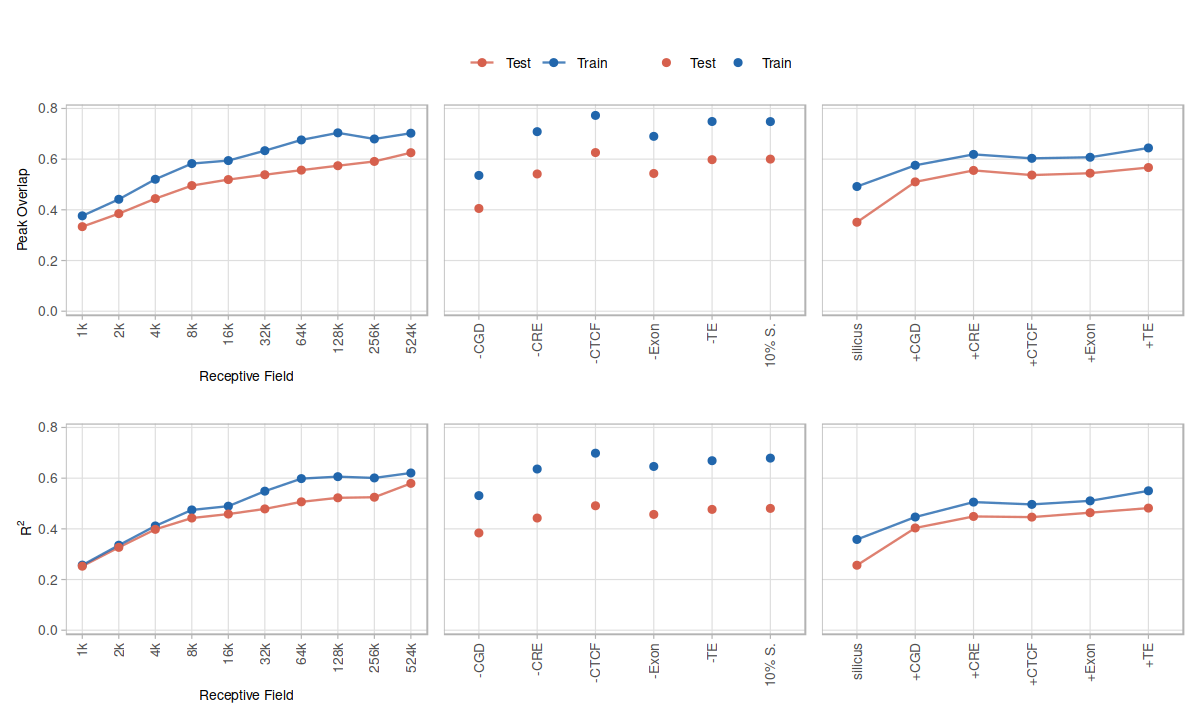

In [13]:
sps(10, 6)
combined_plot

## 13. Combined Plot with silicusTelescopeMm10 (Supplementary)

In [14]:
# --- Combined Plot with silicusTelescopeMm10 variant ---
# Same structure as above but using silicusTelescopeMm10 instead of silicusTelescope

# Plot 3b: Telescope Mm10 (Overlap)
p3b_overlap_tel_mm10 <- plot_performance(
    overlap_k27 %>% 
        filter(series == "silicusTelescopeMm10") %>%
        mutate(genome_label = recode(genome_label, !!!telescope_mapping)),
    metric = "overlap",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = tel_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0.5
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis()

# Plot 6b: Telescope Mm10 (R2)
p6b_rsqr_tel_mm10 <- plot_performance(
    rsqr_k27 %>% 
        filter(series == "silicusTelescopeMm10") %>%
        mutate(genome_label = recode(genome_label, !!!telescope_mapping)),
    metric = "rsqr",
    mark_label = "H3K27me3",
    series_filter = NULL,
    title_suffix = "",
    x_levels = tel_short_levels,
    baseline_data = NULL,
    show_val = FALSE,
    style = "ppt",
    point_size = 1.5, text_size = 2, line_width = 0.5
) +
    ggtitle("") +
    scale_y_continuous(limits = common_ylim, expand = expansion(mult = c(0.02, 0.02))) +
    tgppt::theme_arial(7) +
    vertical_labs() +
    clean_y_axis()

# Combine plots with silicusTelescopeMm10
combined_plot_mm10 <- (p1_overlap_fm | p2_overlap_minus | p3b_overlap_tel_mm10) /
                      (p4_rsqr_fm | p5_rsqr_minus | p6b_rsqr_tel_mm10) +
                      plot_layout(guides = "collect", axis_titles = "collect") & 
                      theme(legend.position = "top", 
                            plot.margin = margin(5, 5, 5, 5))

# Export to single slide
ppt_path_mm10 <- here("figures/k27_all_comparison_mm10_telescope.pptx")
tgppt::plot_base_ppt(print(combined_plot_mm10), ppt_path_mm10, width = 18, height = 12, overwrite = TRUE)

message("Combined plot with silicusTelescopeMm10 saved to ", ppt_path_mm10)

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“ggrepel: 20 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 20 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Combined plot with silicusTelescopeMm10 saved to /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/figures/k27_all_comparison_mm10_telescope.pptx



Warning message:
“ggrepel: 19 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 20 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


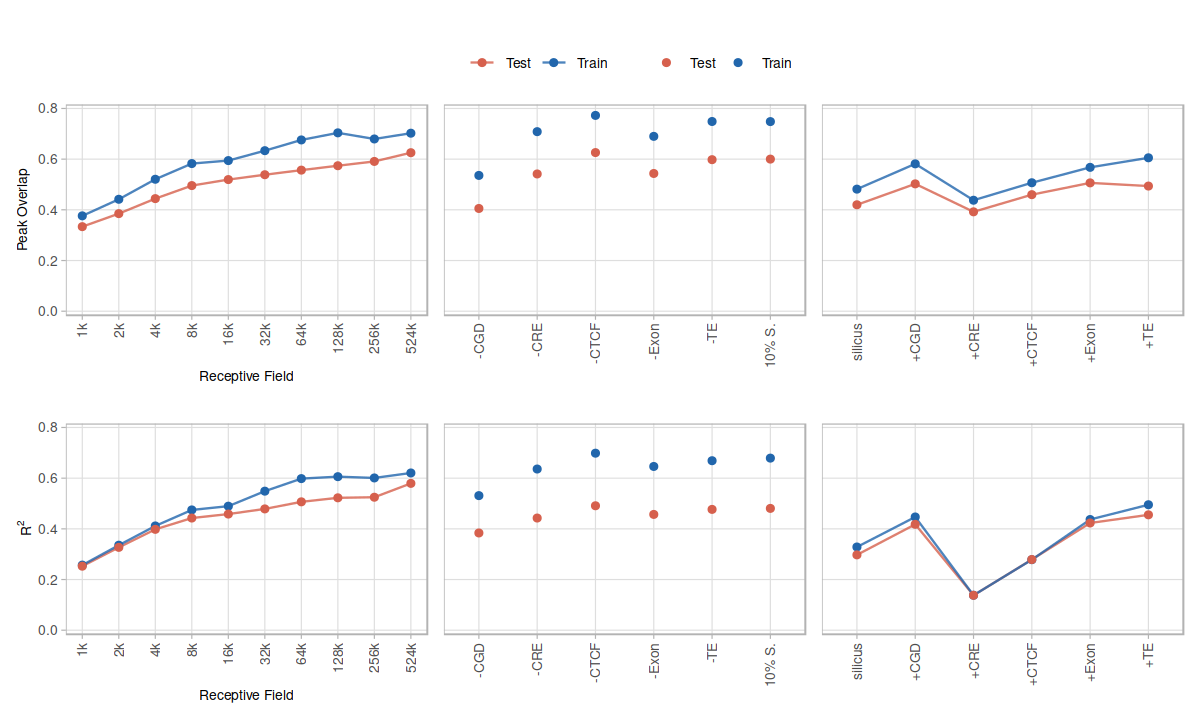

In [15]:
sps(10, 6)
combined_plot_mm10

## 14. Barplot Figure - Test Data Only with SNS Reference (Main Figure)

In [16]:
# --- Barplot: Test Data Only with SNS as a Bar in RF Series ---

# Get SNS reference values (test set)
sns_overlap_test <- if (!is.null(overlap_sns)) overlap_sns$test_p[overlap_sns$col_name == "sns_brz2k"] else NA
sns_rsqr_test <- if (!is.null(rsqr_sns)) rsqr_sns$r2_test[rsqr_sns$col_name == "sns_brz2k"] else NA

# --- 1. Prepare Data: Add SNS row to RF series ---

# Define new levels for RF (appending SNS at the end)
rf_levels_sns <- c(rf_values, "SNS")

# Add SNS row to Overlap Data
rf_overlap_mod <- overlap_rf_k27 %>% 
    # filter(series == "fm") %>%
    filter(series == "flashzoi") %>%
    mutate(genome_label = rf) %>%
    bind_rows(data.frame(
        # series = "fm", 
        series = "flashzoi",
        genome_label = "SNS", 
        test_p = sns_overlap_test
    ))

# Add SNS row to R2 Data
rf_rsqr_mod <- rsqr_rf_k27 %>% 
    # filter(series == "fm") %>%
    filter(series == "flashzoi") %>%
    mutate(genome_label = rf) %>%
    bind_rows(data.frame(
        # series = "fm", 
        series = "flashzoi",
        genome_label = "SNS", 
        r2_test = sns_rsqr_test
    ))

# Other series remain the same
mm10minus_overlap <- overlap_k27 %>% 
    filter(series == "mm10Minus") %>% 
    mutate(genome_label = gsub("mm10", "", genome_label)) %>% 
    mutate(genome_label = gsub("-Random", "10% S.", genome_label)) %>% 
    filter(!grepl("pad", genome_label))

mm10minus_rsqr <- rsqr_k27 %>% 
    filter(series == "mm10Minus") %>% 
    mutate(genome_label = gsub("mm10", "", genome_label)) %>% 
    mutate(genome_label = gsub("-Random", "10% S.", genome_label)) %>% 
    filter(!grepl("pad", genome_label))

telescope_overlap <- overlap_k27 %>% 
    filter(series == "silicusTelescope") %>%
    mutate(genome_label = recode(genome_label, !!!telescope_mapping))

telescope_rsqr <- rsqr_k27 %>% 
    filter(series == "silicusTelescope") %>%
    mutate(genome_label = recode(genome_label, !!!telescope_mapping))


# --- 2. Helper Function with Bar Highlighting ---

plot_barplot_test <- function(data, value_col, y_label, sns_ref = NULL, 
                              x_levels = NULL, ylim = c(0, 0.8),
                              bar_color = "#2C7BB6", sns_color = "red",
                              highlight_bar = NULL, highlight_color = "#E31A1C", # New args
                              x_var = "genome_label",
                              show_sns_label = FALSE) {
    
    plot_data <- data
    if (!is.null(x_levels)) {
        plot_data <- plot_data %>%
            mutate(!!sym(x_var) := factor(.data[[x_var]], levels = x_levels))
    }
    
    # Base Plot
    p <- ggplot(plot_data, aes(x = .data[[x_var]], y = .data[[value_col]]))
    
    # Conditional Fill: Check if we need to highlight a specific bar (e.g., SNS)
    if (!is.null(highlight_bar)) {
        p <- p + geom_col(aes(fill = .data[[x_var]] == highlight_bar), 
                          alpha = 0.8, width = 0.7) +
                 scale_fill_manual(values = c("FALSE" = bar_color, "TRUE" = highlight_color), 
                                   guide = "none")
    } else {
        p <- p + geom_col(fill = bar_color, alpha = 0.8, width = 0.7)
    }

    # Labels and Theme
    p <- p + 
        geom_text(aes(label = round(.data[[value_col]], 2)), 
                  vjust = -0.2, 
                  size = 2) + 
        scale_y_continuous(limits = ylim, expand = expansion(mult = c(0, 0.1))) +
        labs(x = "", y = y_label) +
        tgppt::theme_arial(7) +
        vertical_labs() + # Preserves rotation
        theme(panel.grid.major.y = element_line(color = "gray93"),
              panel.grid.minor.y = element_blank())
    
    # Add SNS reference line (only if provided)
    if (!is.null(sns_ref)) {
        p <- p + 
            geom_hline(yintercept = sns_ref, linetype = "dashed", 
                       color = sns_color, linewidth = 0.8)
            
        if (show_sns_label) {
             p <- p + annotate("text", x = 1, y = sns_ref, # Put label near start
                     label = sprintf("SNS: %.2f", sns_ref),
                     hjust = 0, vjust = -1, size = 2.5, 
                     color = sns_color, fontface = "italic")
        }
    }
    
    return(p)
}


# --- 3. Create Plots ---

# Row 1: Overlap

# RF: Has SNS Bar, No Line
bar_overlap_rf <- plot_barplot_test(
    rf_overlap_mod, "test_p", "Peak Overlap",
    sns_ref = NULL, 
    x_levels = rf_levels_sns, # Use new levels with SNS
    ylim = common_ylim,
    highlight_bar = "SNS" # Highlight the SNS bar
) 

# mm10: No Bar
bar_overlap_minus <- plot_barplot_test(
    mm10minus_overlap, "test_p", "",
    sns_ref = NULL,
    x_levels = mm10_short_levels,
    ylim = common_ylim,
    show_sns_label = TRUE # Label appears here now
) + clean_y_axis()

# Telescope
bar_overlap_tel <- plot_barplot_test(
    telescope_overlap, "test_p", "",
    sns_ref = NULL,
    x_levels = tel_short_levels,
    ylim = common_ylim,
    show_sns_label = FALSE
) + clean_y_axis()


# Row 2: R²

# RF: Has SNS Bar
bar_rsqr_rf <- plot_barplot_test(
    rf_rsqr_mod, "r2_test", expression(R^2),
    sns_ref = NULL,
    x_levels = rf_levels_sns,
    ylim = common_ylim,
    highlight_bar = "SNS"
)

# mm10
bar_rsqr_minus <- plot_barplot_test(
    mm10minus_rsqr, "r2_test", "",
    sns_ref = NULL,
    x_levels = mm10_short_levels,
    ylim = common_ylim,
    show_sns_label = TRUE
) + clean_y_axis()

# Telescope: No Bar
bar_rsqr_tel <- plot_barplot_test(
    telescope_rsqr, "r2_test", "",
    sns_ref = NULL,
    x_levels = tel_short_levels,
    ylim = common_ylim,
    show_sns_label = FALSE
) + clean_y_axis()


# --- 1. Remove X-axis labels from the Top Row (Overlap) ---
# We use element_blank() to remove both the text and the tick marks
theme_no_x <- theme(
  axis.text.x = element_blank(),
  axis.ticks.x = element_blank()
)

bar_overlap_rf    <- bar_overlap_rf + theme_no_x
bar_overlap_minus <- bar_overlap_minus + theme_no_x
bar_overlap_tel   <- bar_overlap_tel + theme_no_x

# --- 2. Combine and Save ---
barplot_combined <- wrap_plots(
    bar_overlap_rf, bar_overlap_minus, bar_overlap_tel,
    bar_rsqr_rf,    bar_rsqr_minus,    bar_rsqr_tel,
    ncol = 3, 
    widths = c(1, 1, 1) # Keep your width settings
) +
plot_layout(axis_titles = "collect") &
theme(plot.margin = margin(10, 10, 5, 5))

# Export
ppt_path_bar <- here("figures/k27_barplot_test_only_v3.pptx")
tgppt::plot_base_ppt(print(barplot_combined), ppt_path_bar, width = 18, height = 10, overwrite = TRUE)

message("Barplot figure saved to ", ppt_path_bar)

Barplot figure saved to /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/figures/k27_barplot_test_only_v3.pptx



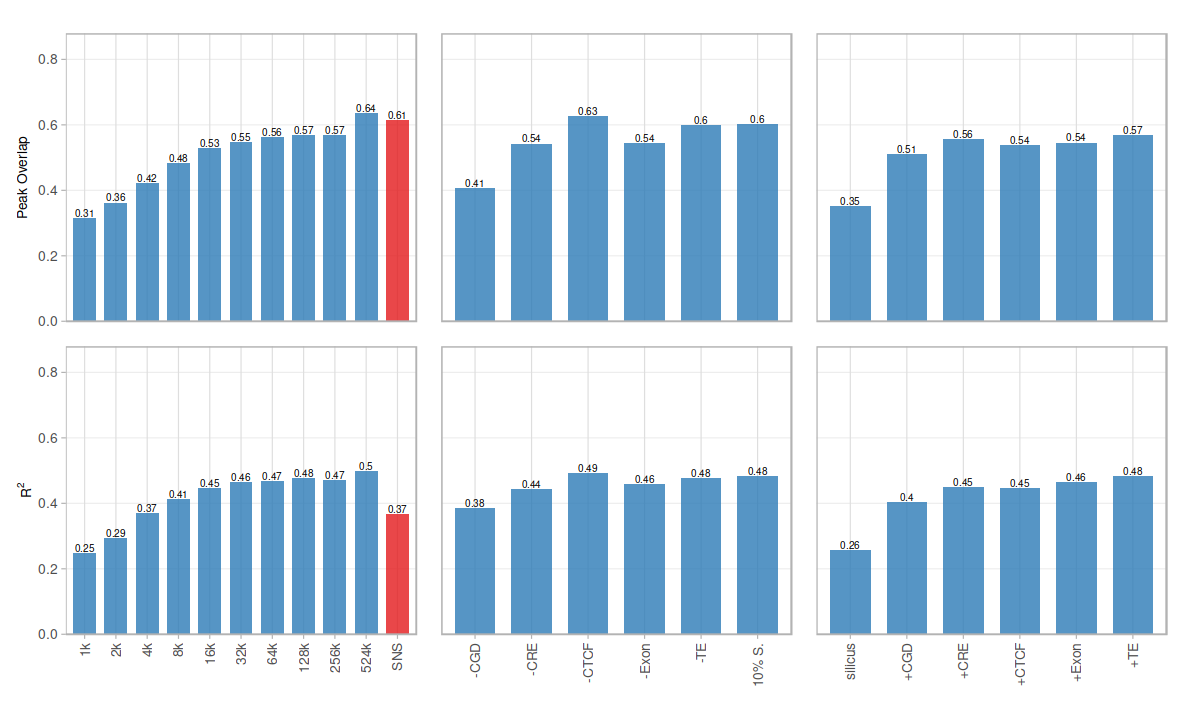

In [17]:
sps(10, 6)
barplot_combined

## 15. Barplot with silicusTelescopeMm10 (Main Figure Variant)

In [18]:
# --- Barplot with silicusTelescopeMm10 variant ---
# Layout: 3 columns (RF | mm10Minus | TelescopeMm10), 2 rows (Overlap | R²)

# Telescope Mm10 series
telescope_mm10_overlap <- overlap_k27 %>% 
    filter(series == "silicusTelescopeMm10") %>%
    mutate(genome_label = recode(genome_label, !!!telescope_mapping))

telescope_mm10_rsqr <- rsqr_k27 %>% 
    filter(series == "silicusTelescopeMm10") %>%
    mutate(genome_label = recode(genome_label, !!!telescope_mapping))

# Barplot: Telescope Mm10 Overlap (test)
bar_overlap_tel_mm10 <- plot_barplot_test(
    telescope_mm10_overlap, "test_p", "",
    sns_ref = NA,
    x_levels = tel_short_levels,
    ylim = common_ylim
) + clean_y_axis() + theme_no_x

# Barplot: Telescope Mm10 R² (test)
bar_rsqr_tel_mm10 <- plot_barplot_test(
    telescope_mm10_rsqr, "r2_test", "",
    sns_ref = NA,
    x_levels = tel_short_levels,
    ylim = common_ylim
) + clean_y_axis()

barplot_combined_mm10 <- wrap_plots(
    bar_overlap_rf, bar_overlap_minus, bar_overlap_tel_mm10,
    bar_rsqr_rf,    bar_rsqr_minus,    bar_rsqr_tel_mm10,
    ncol = 3, 
    widths = c(1.5, 1, 1) # This now correctly sets the column ratios
) +
plot_layout(axis_titles = "collect") &
theme(plot.margin = margin(10, 10, 5, 5))

# Export barplot figure
ppt_path_bar_mm10 <- here("figures/k27_barplot_test_only_mm10_telescope.pptx")
tgppt::plot_base_ppt(print(barplot_combined_mm10), ppt_path_bar_mm10, width = 18, height = 10, overwrite = TRUE)

message("Barplot figure with silicusTelescopeMm10 saved to ", ppt_path_bar_mm10)

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_hline()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_hline()`).”
Barplot figure with silicusTelescopeMm10 saved to /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/seq2epi_paper_norm/figures/k27_barplot_test_only_mm10_telescope.pptx



Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_hline()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_hline()`).”


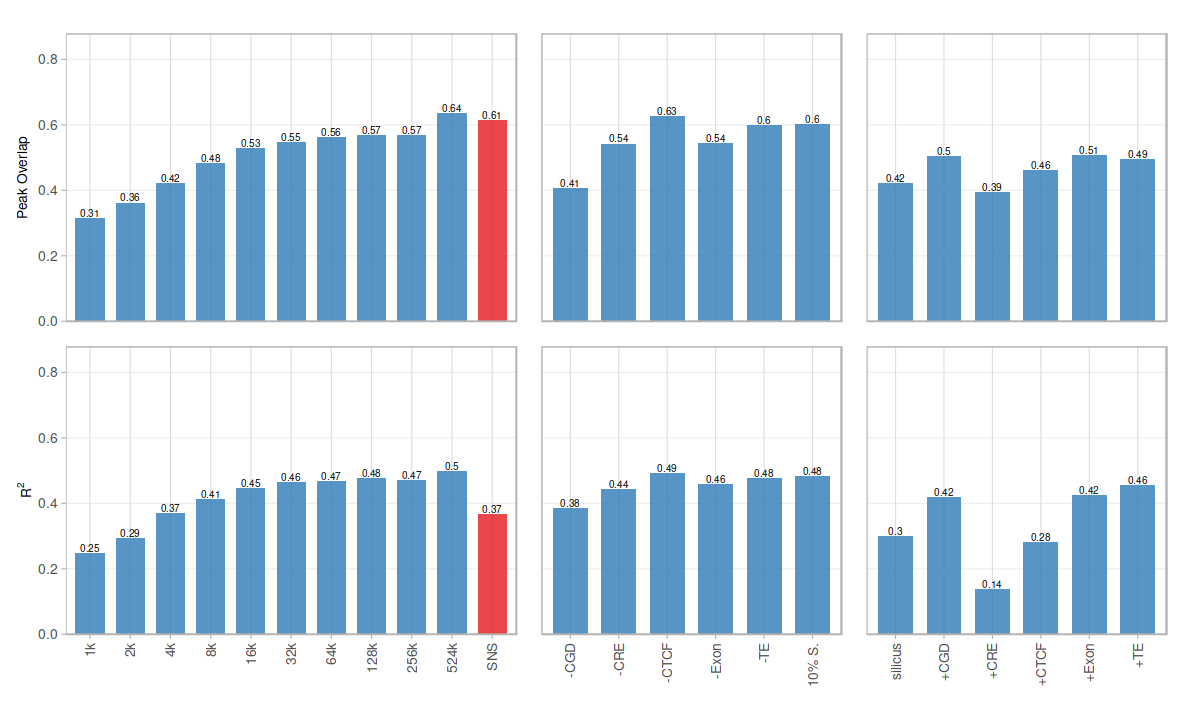

In [19]:
sps(10, 6)
barplot_combined_mm10